# 02 - Splitting

In diesem Notebook wird ein **streng chronologischer** 70/15/15-Split auf `data/processed/features.csv` durchgeführt und als CSV exportiert.

Warum chronologisch? Bei Zeitreihen würde ein zufälliger Split zu Data Leakage führen, weil Informationen aus der Zukunft indirekt ins Training gelangen könnten.

Die Splits sind daher bewusst als **Train (Vergangenheit) -> Validation (später) -> Test (jüngster Zeitraum)** definiert.

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

TARGET = 'Solarproduktion'
DATA_PATH = Path('../data/processed/features.csv')
OUT_DIR = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Autumn']


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

n = len(df)
val_start = int(n * 0.70)
test_start = int(n * 0.85)

train = df.iloc[:val_start].copy()
val = df.iloc[val_start:test_start].copy()
test = df.iloc[test_start:].copy()

print(f'Train: {len(train):,} rows')
print(f'Val  : {len(val):,} rows')
print(f'Test : {len(test):,} rows')


Train: 82,334 rows
Val  : 17,643 rows
Test : 17,643 rows


## Visualisierung des Splits über den gesamten Zeitraum

Die folgenden Punkte zeigen `Solarproduktion` über die Zeit, farblich codiert nach Split: **Train (blau)**, **Validation (orange)**, **Test (grün)**.

AttributeError: module 'matplotlib.dates' has no attribute 'NullLocator'

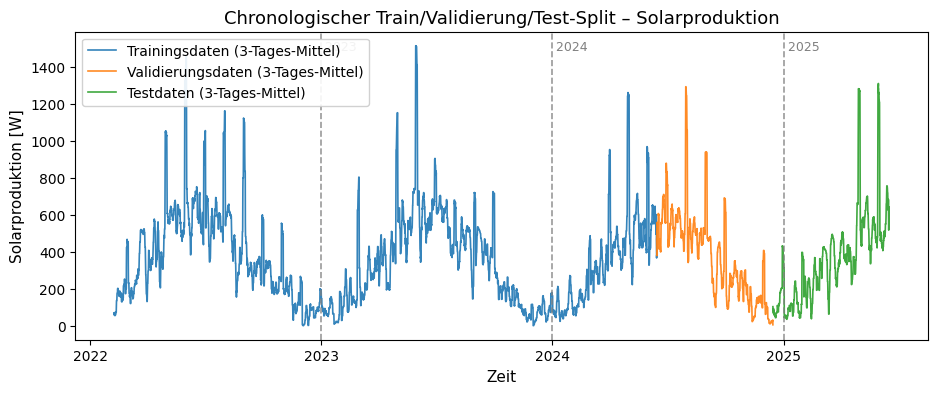

In [3]:
import matplotlib.dates as mdates

# Gleitender Mittelwert (3 Tage = 3 × 96 × 15-min-Intervalle)
WINDOW = 3 * 96
train_roll = train.set_index('timestamp')[TARGET].rolling(WINDOW, center=True, min_periods=WINDOW // 2).mean()
val_roll   = val.set_index('timestamp')[TARGET].rolling(WINDOW, center=True, min_periods=WINDOW // 2).mean()
test_roll  = test.set_index('timestamp')[TARGET].rolling(WINDOW, center=True, min_periods=WINDOW // 2).mean()

fig, ax = plt.subplots(figsize=(11, 4), facecolor='white')
ax.set_facecolor('white')

ax.plot(train_roll.index, train_roll, linewidth=1.2, alpha=0.9, label='Trainingsdaten (3-Tages-Mittel)', color='tab:blue')
ax.plot(val_roll.index,   val_roll,   linewidth=1.2, alpha=0.9, label='Validierungsdaten (3-Tages-Mittel)', color='tab:orange')
ax.plot(test_roll.index,  test_roll,  linewidth=1.2, alpha=0.9, label='Testdaten (3-Tages-Mittel)', color='tab:green')

# Jahreswechsel hervorheben
year_min = train['timestamp'].dt.year.min()
year_max = test['timestamp'].dt.year.max()
for year in range(year_min + 1, year_max + 1):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1] * 0.97,
            f' {year}', color='gray', fontsize=9, va='top')

ax.set_title('Chronologischer Train/Validierung/Test-Split – Solarproduktion', fontsize=13)
ax.set_xlabel('Zeit', fontsize=11)
ax.set_ylabel('Solarproduktion [W]', fontsize=11)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.NullLocator())

ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')
plt.tight_layout()
plt.show()


In [ ]:
def split_summary(train_df, val_df, test_df):
    total = len(train_df) + len(val_df) + len(test_df)
    rows = []
    for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        rows.append({
            'split': name,
            'from': split_df['timestamp'].min(),
            'to': split_df['timestamp'].max(),
            'n': len(split_df),
            'share': f"{len(split_df)/total:.1%}",
        })
    return pd.DataFrame(rows).set_index('split')

def split_season_distribution(train_df, val_df, test_df):
    rows = {}
    for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        seasons = split_df['timestamp'].dt.month.map(SEASON_MAP)
        counts = seasons.value_counts(normalize=True).reindex(SEASON_ORDER, fill_value=0.0)
        rows[name] = counts.round(3)
    return pd.DataFrame(rows).T

split_summary(train, val, test)


In [ ]:
split_season_distribution(train, val, test)

In [ ]:
# train.to_csv(OUT_DIR / 'train.csv', index=False)
# val.to_csv(OUT_DIR / 'val.csv', index=False)
# test.to_csv(OUT_DIR / 'test.csv', index=False)

# print('Saved:', OUT_DIR / 'train.csv')
# print('Saved:', OUT_DIR / 'val.csv')
# print('Saved:', OUT_DIR / 'test.csv')
